In [127]:
import os 
import sys
import time
import warnings
os.system('clear')
warnings.filterwarnings("ignore")



import numpy as np
import torch 
# import torch.nn as nn
# import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
torch.set_printoptions(threshold=512, linewidth=512)

hostname = os.uname()
if 'tycho' in hostname:
    # Common folder is already in the path
    pass
elif 'tedtop' in hostname:
    print('Setting up paths for tedtop')
    sys.path.append('/home/fedor-tairli/work/CDEs/Dataset/')
elif 'ycho' in hostname: 
    sys.path.append('/remote/tychodata/ftairli/work/Projects/Common/')

from Dataset2 import ProcessingDatasetContainer






from matplotlib import pyplot as plt

In [128]:
from importlib import reload

import Toy_TimeFit_Model_Sup as sup
reload(sup)

TimeFitEq_Toy = sup.TimeFitEq_Toy
Loss_function = sup.Loss
validate = sup.validate
metric = sup.metric

Model = sup.Model_Toy_Autoencoder_TimeFit


from TrainingModule import Train , Tracker

In [129]:
def Return_as_is(Truth):
    return Truth
  

def generate_toy_data(Dataset,N_events = 1e6):

    

    chi_0_range = (0,torch.pi)
    rp_range    = (0,50)
    t0_range    = (0,160)

    Sparse_Data = []
    Truth = torch.zeros((int(N_events),3))

    for i in range(int(N_events)):
        if i%1000 == 0:
            print(f'Generating event {i} / {int(N_events)}',end = '\r')
        
        Chi_0 = torch.tensor(np.random.uniform(*chi_0_range),dtype = torch.float32)
        Rp    = torch.tensor(np.random.uniform(*rp_range),dtype = torch.float32)
        T0    = torch.tensor(np.random.uniform(*t0_range),dtype = torch.float32)

        N_Samples = torch.tensor(np.random.randint(25,50))
        chi_i     = torch.tensor(np.linspace(0,Chi_0,N_Samples),dtype = torch.float32)

        Time_i = TimeFitEq_Toy(chi_i,Chi_0,Rp,T0)
        station_chi_i = torch.tensor([0])
        station_time_i = TimeFitEq_Toy(station_chi_i,Chi_0,Rp,T0)

        event_data = {
            'chi_i': chi_i,
            'time' : Time_i,
            'station_chi_i': station_chi_i,
            'station_time': station_time_i
        }
        Sparse_Data.append(event_data)
        Truth[i] = torch.tensor([Chi_0,Rp,T0])

    if Dataset is None:
        return Sparse_Data, Truth
    
    else:
        Dataset._Graph = Sparse_Data
        Dataset.GraphData =True
        Dataset._Truth = Truth
        
        Dataset.Unnormalise_Truth = Return_as_is
        Dataset.Truth_Keys = ['Chi_0','Rp','T0']
        Dataset.Truth_Units = ['rad','m','s']
        Dataset._Rec = Truth

        
        Dataset._Aux = Truth
        Dataset.Aux_Keys = ['Chi_0','Rp','T0']
        Dataset.Aux_Units = ['rad','m','s']

        Dataset._EventIds = torch.arange(int(N_events))
        return Dataset

Sparse_Data, Truth = generate_toy_data(None,N_events = 10)


print(Truth[0] )
print(Sparse_Data[0] )


tensor([  2.2992,   2.4549, 122.8719])
{'chi_i': tensor([0.0000, 0.0575, 0.1150, 0.1724, 0.2299, 0.2874, 0.3449, 0.4024, 0.4598, 0.5173, 0.5748, 0.6323, 0.6898, 0.7472, 0.8047, 0.8622, 0.9197, 0.9772, 1.0346, 1.0921, 1.1496, 1.2071, 1.2646, 1.3220, 1.3795, 1.4370, 1.4945, 1.5520, 1.6094, 1.6669, 1.7244, 1.7819, 1.8394, 1.8968, 1.9543, 2.0118, 2.0693, 2.1268, 2.1843, 2.2417, 2.2992]), 'time': tensor([128.5162, 128.3751, 128.2340, 128.0929, 127.9518, 127.8107, 127.6695, 127.5284, 127.3873, 127.2462, 127.1051, 126.9640, 126.8229, 126.6818, 126.5407, 126.3996, 126.2585, 126.1174, 125.9763, 125.8352, 125.6940, 125.5529, 125.4118, 125.2707, 125.1296, 124.9885, 124.8474, 124.7063, 124.5652, 124.4241, 124.2830, 124.1419, 124.0008, 123.8596, 123.7185, 123.5774, 123.4363, 123.2952, 123.1541, 123.0130, 122.8719]), 'station_chi_i': tensor([0]), 'station_time': tensor([128.5162])}


In [130]:
# make a million random events
Dataset_Name  = 'Toy_TimeFit_Sup_Dataset'
Recalculate = True
# Check if Dataset_Name already exists

Dataset = ProcessingDatasetContainer()
Dataset = generate_toy_data(Dataset)

Dataset.set_Name(Dataset_Name)
Dataset.Save('.',Name = Dataset_Name)

Dataset.AssignIndices()
Dataset.RandomIter = True
print(f' Dataset {Dataset.Name} loaded with {len(Dataset)} events. ')

 Dataset Toy_TimeFit_Sup_Dataset loaded with 1000000 events. 


In [131]:
Model_Parameters = {
    'in_main_channels': (2,)  ,
    'pixel_embedding_size': 32,
    'latent_space_size'   : 32,
    'Train_Type'      : 'Profile', # Profile, Geometry or Both
    'N_dense_nodes'   : 128   ,
}

Training_Parameters = {
            'LR': 0.001,
            'epochs': 150,
            'BatchSize': 64,
            'accumulation_steps': 1,
            'epoch_done': 0,
            'batchBreak': 1e99,
            'ValLossIncreasePatience': 5,
            'Optimiser': 'Adam',
            'Debug_Mode': False
        }

Dataset.BatchSize = Training_Parameters['BatchSize']

In [132]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Model(**Model_Parameters).to(device)

optimiser = optim.Adam(model.parameters(), lr=Training_Parameters['LR'])
if Training_Parameters['Optimiser'] == 'SGD' : optimizer = optim.SGD (model.parameters(), lr=Training_Parameters['LR'], momentum=0.9)


gamma = 0.001**(1/30) if Training_Parameters['epochs']>30 else 0.001**(1/Training_Parameters['epochs']) # Reduce the LR by factor of 1000 over 30 epochs or less
print(f'Gamma in LR Reduction: {gamma}')
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimiser, gamma = gamma, last_epoch=-1)


print('Training model: '     ,model.Name)
print('Accumulation Steps: ' ,Training_Parameters['accumulation_steps'])
Dataset.BatchSize =           Training_Parameters['BatchSize']
print('Batch Size: '         ,Dataset.BatchSize)


Gamma in LR Reduction: 0.7943282347242815
Training model:  Model_Toy_Autoencoder_TimeFit
Accumulation Steps:  1
Batch Size:  64


In [133]:
model,tracker = Train(model,Dataset,optimiser,scheduler,Loss_function,validate,metric ,Tracker,device = device,\
                                plotOnEpochCompletionPath=None,Training_Parameters=Training_Parameters,Model_Parameters=Model_Parameters,LogPath=None)
           

Epoch 1/150
Batch 10900 /10937 - Loss: 0.5552
Epoch Loss: 33.6235 | Epoch Val Loss: 1.0804
Profile_chii Val Loss: 0.0033 |Profile_time Val Loss: 1.0771 |Chi_0 Val Loss: 0.0000e+00 |Rp Val Loss: 0.0000e+00 |T0 Val Loss: 0.0000e+00 |Total Val Loss: 1.0804 |
Chi_0 : 0.0000 s |Rp : 0.0000 deg |T0 : 0.0000 m |Profile : 0.0000 ns |
-------------------------------------
Epoch 2/150
Batch 10900 /10937 - Loss: 2.5503
Epoch Loss: 11.2673 | Epoch Val Loss: 3.0546
Profile_chii Val Loss: 0.0029 |Profile_time Val Loss: 3.0518 |Chi_0 Val Loss: 0.0000e+00 |Rp Val Loss: 0.0000e+00 |T0 Val Loss: 0.0000e+00 |Total Val Loss: 3.0546 |
Chi_0 : 0.0000 s |Rp : 0.0000 deg |T0 : 0.0000 m |Profile : 0.0000 ns |
-------------------------------------
Epoch 3/150
Batch 10900 /10937 - Loss: 0.4476
Epoch Loss: 1.8931 | Epoch Val Loss: 0.9754
Profile_chii Val Loss: 0.0011 |Profile_time Val Loss: 0.9743 |Chi_0 Val Loss: 0.0000e+00 |Rp Val Loss: 0.0000e+00 |T0 Val Loss: 0.0000e+00 |Total Val Loss: 0.9754 |
Chi_0 : 0.000

KeyboardInterrupt: 

[{'chi_i': tensor([0.0000, 0.0204, 0.0408, 0.0612, 0.0816, 0.1020, 0.1224, 0.1427, 0.1631, 0.1835, 0.2039, 0.2243, 0.2447, 0.2651, 0.2855, 0.3059, 0.3263, 0.3467, 0.3671, 0.3874, 0.4078, 0.4282, 0.4486, 0.4690, 0.4894, 0.5098, 0.5302, 0.5506, 0.5710, 0.5914, 0.6118, 0.6321, 0.6525, 0.6729, 0.6933, 0.7137]), 'time': tensor([122.6380, 122.6362, 122.6343, 122.6325, 122.6307, 122.6289, 122.6271, 122.6253, 122.6235, 122.6216, 122.6198, 122.6180, 122.6162, 122.6144, 122.6126, 122.6107, 122.6089, 122.6071, 122.6053, 122.6035, 122.6017, 122.5998, 122.5980, 122.5962, 122.5944, 122.5926, 122.5908, 122.5890, 122.5871, 122.5853, 122.5835, 122.5817, 122.5799, 122.5781, 122.5762, 122.5744]), 'station_chi_i': tensor([0]), 'station_time': tensor([122.6380])}]
tensor([[7.1371e-01, 8.9043e-02, 1.2257e+02]])
tensor([[7.1371e-01, 8.9043e-02, 1.2257e+02]])
tensor([[0.0000],
        [0.0793],
        [0.1586],
        [0.2379],
        [0.3172],
        [0.3965],
        [0.4758],
        [0.5551],
        

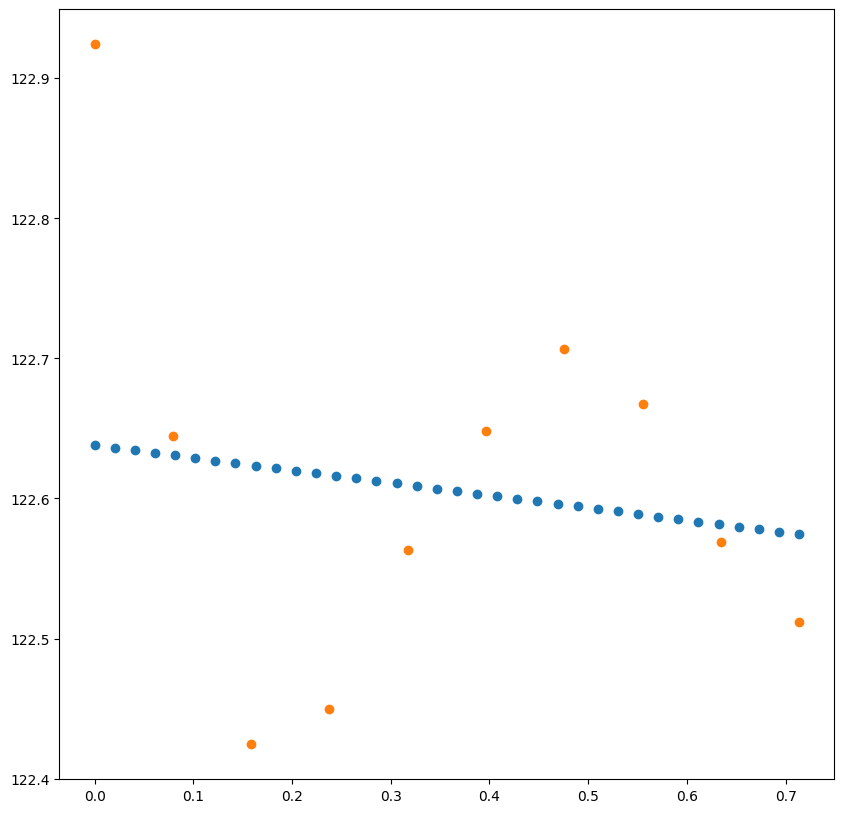

In [236]:
Dataset.State = 'Test'
Dataset.BatchSize = 1

model.eval()
with torch.no_grad():

    for _, BatchMain, BatchAux, BatchTruth, _ in Dataset:
        print(BatchMain)
        print(BatchAux)
        print(BatchTruth)
        break

    Model_Out = model(BatchMain,BatchAux)

plt.figure(figsize=(10,10))
plt.scatter(BatchMain[0]['chi_i'],BatchMain[0]['time'])

pred_chi_i = Model_Out['test_chi_is'][0].cpu()
pred_time  = Model_Out['time_profile'][0,:,1].cpu()

print(pred_chi_i)
print(pred_time)

plt.scatter(pred_chi_i,pred_time)